<a href="https://colab.research.google.com/github/0517kkm-blip/-/blob/main/%ED%95%B4%EC%82%AC%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%A7%88%EC%9D%B4%EB%8B%9D%206%EC%A3%BC%EC%B0%A8%20%EA%B3%BC%EC%A0%9C%2020230525%20%EA%B9%80%EA%B7%9C%EB%AF%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab 시작 페이지

In [1]:
import pandas as pd

# 데이터 로드 (URL 이용)
train = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part2/ch7/score_train.csv")
test = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part2/ch7/score_test.csv")

In [2]:
# 데이터 크기 확인
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

# 데이터 정보(자료형) 확인
print(train.info())

# 결측치 확인
print("train 결측치 수:", train.isnull().sum().sum())
print("test 결측치 수:", test.isnull().sum().sum())

# 타겟(Credit_Score) 빈도 확인
print(train['Credit_Score'].value_counts())

Train Shape: (4198, 21)
Test Shape: (1499, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4198 entries, 0 to 4197
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Delay_from_due_date       4198 non-null   float64
 1   Num_of_Delayed_Payment    4198 non-null   float64
 2   Num_Credit_Inquiries      4198 non-null   float64
 3   Credit_Utilization_Ratio  4198 non-null   float64
 4   Credit_History_Age        4198 non-null   float64
 5   Payment_of_Min_Amount     4198 non-null   object 
 6   Amount_invested_monthly   4198 non-null   float64
 7   Monthly_Balance           4198 non-null   float64
 8   Credit_Mix                4198 non-null   object 
 9   Payment_Behaviour         4198 non-null   object 
 10  Age                       4198 non-null   float64
 11  Annual_Income             4198 non-null   float64
 12  Num_Bank_Accounts         4198 non-null   float64
 13  Num_Credit_Card 

In [3]:
# 타겟 컬럼 분리
target = train.pop('Credit_Score')

# 범주형 변수를 숫자로 변환 (원-핫 인코딩)
train = pd.get_dummies(train)
test = pd.get_dummies(test)

In [4]:
from sklearn.model_selection import train_test_split

# 8:2 비율로 분할
X_tr, X_val, y_tr, y_val = train_test_split(train, target, test_size=0.2, random_state=0)
print(X_tr.shape, X_val.shape, y_tr.shape, y_val.shape)

(3358, 29) (840, 29) (3358,) (840,)


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# 모델 학습
rf = RandomForestClassifier(random_state=0)
rf.fit(X_tr, y_tr)

# 검증 데이터 예측 및 평가 (f1-macro)
pred = rf.predict(X_val)
f1 = f1_score(y_val, pred, average='macro')
print('f1-macro:', f1)

f1-macro: 0.7004593488873695


In [6]:
# 테스트 데이터 예측
pred = rf.predict(test)

# 결과 저장
submit = pd.DataFrame({'pred': pred})
submit.to_csv("result.csv", index=False)

# 제출 파일 확인
print(pd.read_csv("result.csv").head())

       pred
0      Poor
1      Good
2  Standard
3      Good
4  Standard


In [7]:
import pandas as pd

train = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part4/ch5/train.csv")
test = pd.read_csv("https://raw.githubusercontent.com/lovedlim/bigdata_analyst_cert/main/part4/ch5/test.csv")

In [8]:
# 평가 지표로 RMSE 사용
from sklearn.metrics import root_mean_squared_error

# (코드 흐름상 RandomForestRegressor 등을 활용하여 학습 후 평가 진행)
# f1_score 대신 root_mean_squared_error(y_val, pred) 형식을 사용함

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64
model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object
Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize'], dtype='object')
Index(['model', 'transmission', 'fuelType'], dtype='object')
          model         year         price transmission        mileage  \
count      3759  3759.000000   3759.000000         3759    3759.000000   
unique       19          NaN           NaN            3            NaN   
top      Fiesta          NaN           NaN       Manual            NaN   
freq       1372          NaN           NaN         3234            NaN   
mean        NaN  2016.887736  12353.321362          NaN   23191.786379   
std       

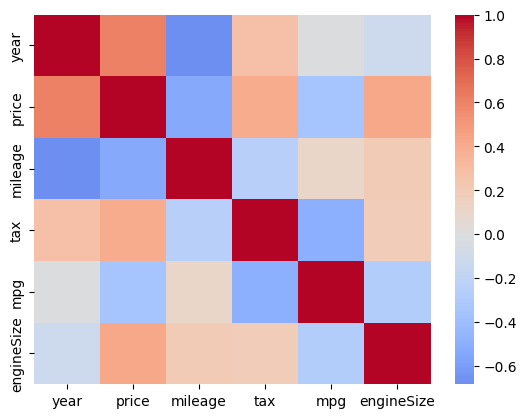

In [10]:
# 1. 결측치 확인
df = train # train 데이터를 df 변수에 할당 (또는 test 데이터를 사용할 경우 df = test)
# TARGET 변수가 정의되지 않아 주석 처리합니다. 필요에 따라 TARGET = '컬럼명' 형태로 정의해주세요.
print(df.isna().sum().sort_values(ascending=False))

# 2. 자료형 확인
print(df.dtypes)
print(df.select_dtypes(include="number").columns) # 수치형
print(df.select_dtypes(exclude="number").columns) # 범주형

# 3. 기초 통계
print(df.describe(include="all"))

# 4. 타겟 분포 확인
# print(df[TARGET].value_counts(dropna=False)) # TARGET 변수 정의 필요

# 5. 상관관계 시각화 (Seaborn 활용)
corr = df.select_dtypes(include="number").corr()
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.show()